RNN and MLP Performance Analysis Based on Number of Trajectories

Results observation: The RNN benefitted significantly more from increasing the number of training trajectories than the MLP did. This suggests that the RNN was able to obtain a more complete picture of the gridworld and thus be more aware of its position.

In [16]:
import os
import sys

REMOTE_PROJECT = "/mnt/d/remote/Levenstein"

os.chdir(REMOTE_PROJECT)

if REMOTE_PROJECT not in sys.path:
    sys.path.insert(0, REMOTE_PROJECT)

print("Running from:", os.getcwd())
print(os.listdir())

Running from: /mnt/d/remote/Levenstein
['.gitgnore', '.venv', '.vscode', 'Experiments', 'functions', 'gridworld_experiment_SimpleMLP.py', 'loss.png', 'plot.png', 'Pytorch Tutorial', 'Sequential predictive learning is a unifying theory for hippocampal representation.pdf', '__pycache__']


In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Imports

In [18]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
    
from IPython.display import display, Markdown
import functions.trajectories as trajectories
import functions.NN_models as NN_models
import functions.gridworld as gridworld
import functions.model_training_evaluator as model_training_evaluator
import functions.dataset_generator as dataset_generator
import numpy as np
import pandas as pd
import torch
from torch import nn
import matplotlib.pyplot as plt

print(sys.executable)
print(torch.__version__)

/home/sebil/miniconda3/envs/main/bin/python
2.10.0+cu128


State variables

In [19]:

HEIGHT = 29
WIDTH = 36
VIEW_SIZE = 5

START_X = 7
START_Y = 7
START_DIRECTION = 2

N_STEPS = 500
N_TRAJ = 20

ACTION_PROBS = [0.6, 0.15, 0.15, 0.1]
ACTION_PROBS_TURN_HEAVY = [0.3, 0.35, 0.35, 0.0]

SEED = 42
TRAINER_MOVE_SEED = 100
TRAINER_START_SEED = 150
VALIDATOR_MOVE_SEED = 300
VALIDATOR_START_SEED = 350

TEST_SEED = 123
TEST_STEPS = 200

TRAINING_EPOCHS = 3000

Gridworld Creation

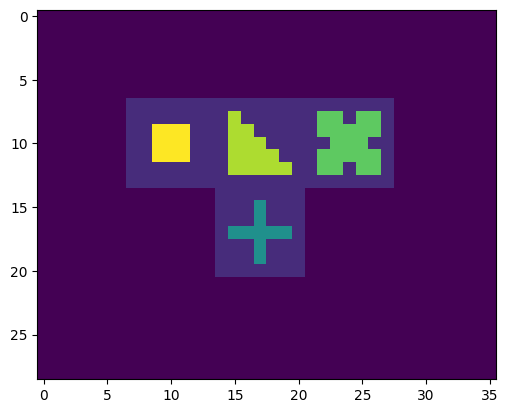

In [20]:
grid = gridworld.GridWorld(HEIGHT, WIDTH)
grid.add_rectangle_region(7, 14, 7, 28)
grid.add_rectangle_region(14, 21, 14, 21)
grid.add_square_shape(9, 9, 3, 7)
grid.add_triangle_shape(8, 15, 5, 0, 6)
grid.add_square_shape(9, 23, 3, 5)
grid.add_square_shape(8, 22, 2, 5)
grid.add_square_shape(11, 22, 2, 5)
grid.add_square_shape(11, 25, 2, 5)
grid.add_square_shape(8, 25, 2, 5)
grid.add_rectangle_shape(15, 17, 5, 1, 3)
grid.add_rectangle_shape(17, 15, 1, 5, 3)
plt.imshow(grid.grid)


NN Training and Validation

Number of trajectories: 20
MLP Trainer final loss: 0.830003559589386
MLP Validator final loss: 0.9761696457862854


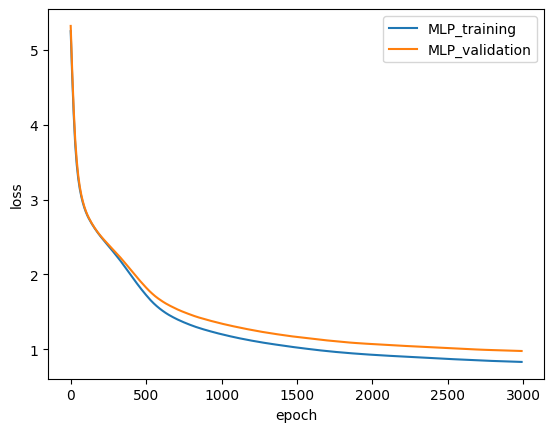

RNN Trainer final loss: 0.7568078637123108
RNN Validator final loss: 0.9421408772468567


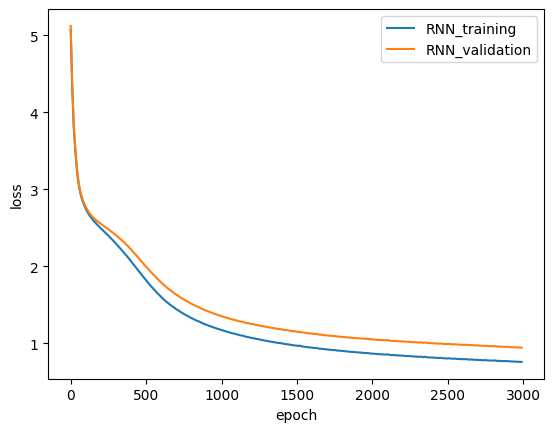

Baseline loss:  4.591728210449219
Baseline loss:  4.676159858703613
Number of trajectories: 40
MLP Trainer final loss: 0.8766838312149048
MLP Validator final loss: 0.94632887840271


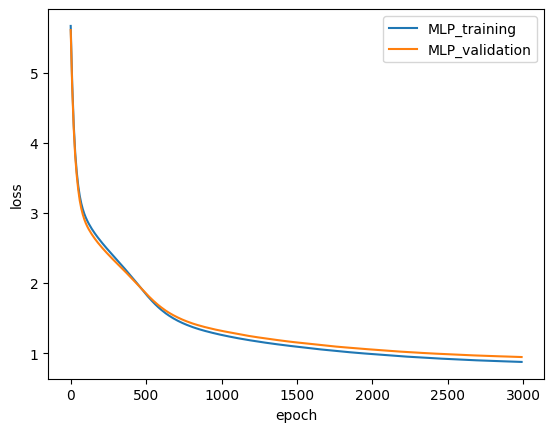

RNN Trainer final loss: 0.7469803690910339
RNN Validator final loss: 0.8374006152153015


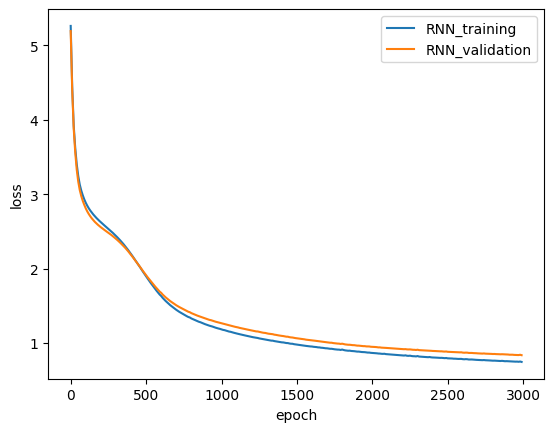

Baseline loss:  4.7241621017456055
Baseline loss:  4.676159858703613
Number of trajectories: 80
MLP Trainer final loss: 0.8507243990898132
MLP Validator final loss: 0.9139543771743774


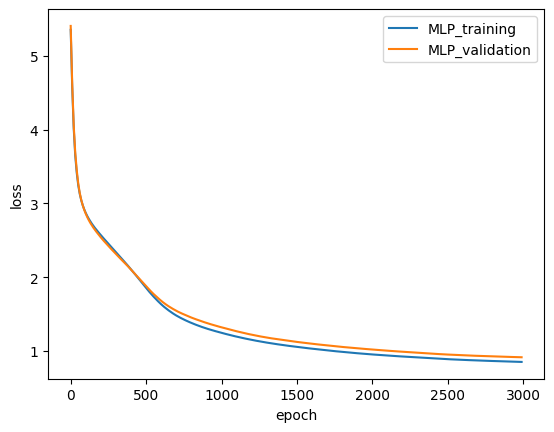

RNN Trainer final loss: 0.7778485417366028
RNN Validator final loss: 0.8550366163253784


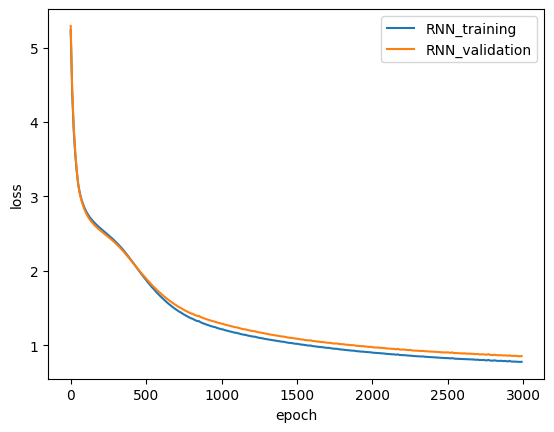

Baseline loss:  4.626364231109619
Baseline loss:  4.676159858703613


,0,1,2
Trajectory count,20.000000,40.000000,80.000000
Trainer MLP Loss,0.830004,0.876684,0.850724
Trainer RNN Loss,0.756808,0.746980,0.777849
Validator MLP Loss,0.976170,0.946329,0.913954
Validator RNN Loss,0.942141,0.837401,0.855037


In [21]:
traj_num = N_TRAJ

traj_list = []
trainer_MLP_loss_list = []
trainer_RNN_loss_list = []
validator_MLP_loss_list = []
validator_RNN_loss_list = []

for i in range(3):
    traj_list.append(traj_num)
    #Generate trainer and validator agents
    print(f"Number of trajectories: {traj_num}")
    trainer_inputs_stack, trainer_target_stack, trainer_agent_list = dataset_generator.generate_dataset(grid, trajectories.random_policy, ACTION_PROBS, VIEW_SIZE, N_STEPS, traj_num, TRAINER_MOVE_SEED, random_start=True, start_seed_start=TRAINER_START_SEED)
    validator_inputs_stack, validator_target_stack, validator_agent_list = dataset_generator.generate_dataset(grid, trajectories.random_policy, ACTION_PROBS, VIEW_SIZE, N_STEPS, 5, VALIDATOR_MOVE_SEED, random_start=True, start_seed_start=VALIDATOR_START_SEED)

    #Train MLP

    INPUT_SIZE = trainer_inputs_stack.shape[2]
    OUTPUT_SIZE = trainer_target_stack.shape[2]
    HIDDEN_SIZE = 64     

    model_MLP = NN_models.SimpleMLP(INPUT_SIZE, OUTPUT_SIZE, HIDDEN_SIZE, "relu")
    MLP_loss_info = model_training_evaluator.model_training(model_MLP, trainer_inputs_stack, trainer_target_stack, validator_inputs_stack, validator_target_stack, TRAINING_EPOCHS)
    print(f"MLP Trainer final loss: {MLP_loss_info[1][-1]}")
    print(f"MLP Validator final loss: {MLP_loss_info[2][-1]}")
    
    model_training_evaluator.plot_training_result(MLP_loss_info, "epoch", "loss", "MLP_training", "MLP_validation")

    trainer_MLP_loss_list.append(MLP_loss_info[1][-1])
    validator_MLP_loss_list.append(MLP_loss_info[2][-1])
    #Train RNN

    model_RNN = NN_models.BasicRNN(INPUT_SIZE, OUTPUT_SIZE, HIDDEN_SIZE, "relu")
    RNN_loss_info = model_training_evaluator.model_training(model_RNN, trainer_inputs_stack, trainer_target_stack, validator_inputs_stack, validator_target_stack, TRAINING_EPOCHS)
    print(f"RNN Trainer final loss: {RNN_loss_info[1][-1]}")
    print(f"RNN Validator final loss: {RNN_loss_info[2][-1]}")
    
    model_training_evaluator.plot_training_result(RNN_loss_info, "epoch", "loss", "RNN_training", "RNN_validation")


    trainer_RNN_loss_list.append(RNN_loss_info[1][-1])
    validator_RNN_loss_list.append(RNN_loss_info[2][-1])


    #Baseline Loss Evaluation

    model_training_evaluator.baseline_evaluation(trainer_inputs_stack, trainer_target_stack)
    model_training_evaluator.baseline_evaluation(validator_inputs_stack, validator_target_stack)

    traj_num *= 2

results_table_array = []

results_table_array.append(traj_list)
results_table_array.append(trainer_MLP_loss_list)
results_table_array.append(trainer_RNN_loss_list)
results_table_array.append(validator_MLP_loss_list)
results_table_array.append(validator_RNN_loss_list)

results = pd.DataFrame(
    results_table_array,
    index = ["Trajectory count", "Trainer MLP Loss", "Trainer RNN Loss", "Validator MLP Loss", "Validator RNN Loss"]
)

results

Turn-Heavy Trajectory run

MLP Trainer final loss: 1.3994776010513306
MLP Validator final loss: 1.4886670112609863


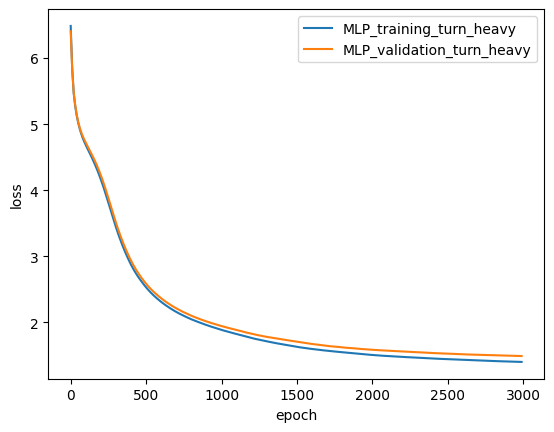

RNN Trainer final loss: 0.8516278862953186
RNN Validator final loss: 0.9873042106628418


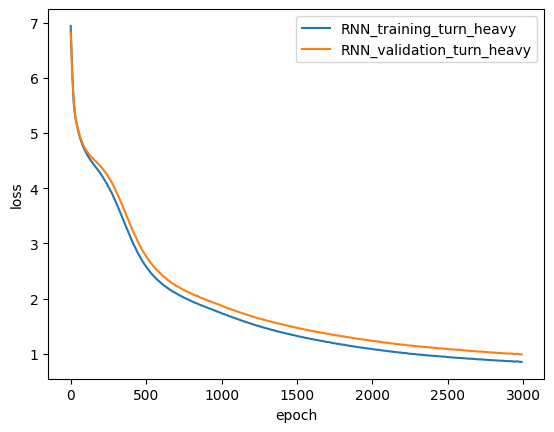

Baseline loss:  9.019743919372559
Baseline loss:  9.019743919372559
MLP Trainer final loss: 1.4315425157546997
MLP Validator final loss: 1.4028632640838623


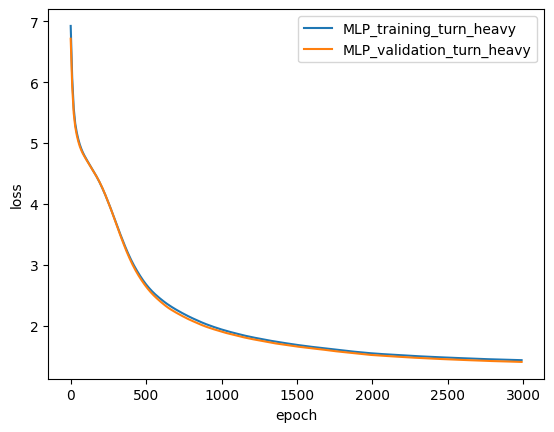

RNN Trainer final loss: 0.8335018157958984
RNN Validator final loss: 0.8767504096031189


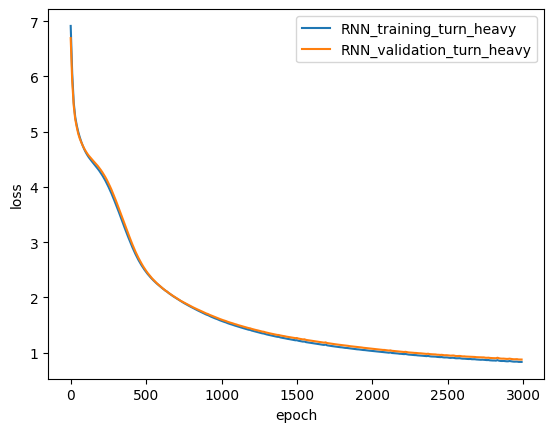

Baseline loss:  9.019743919372559
Baseline loss:  9.019743919372559
MLP Trainer final loss: 1.4661251306533813
MLP Validator final loss: 1.4204683303833008


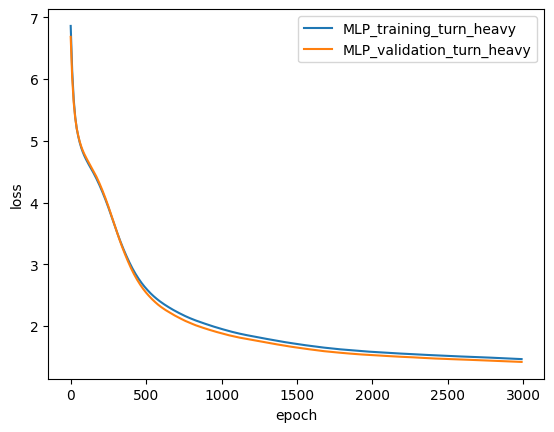

RNN Trainer final loss: 0.8085756897926331
RNN Validator final loss: 0.8143420815467834


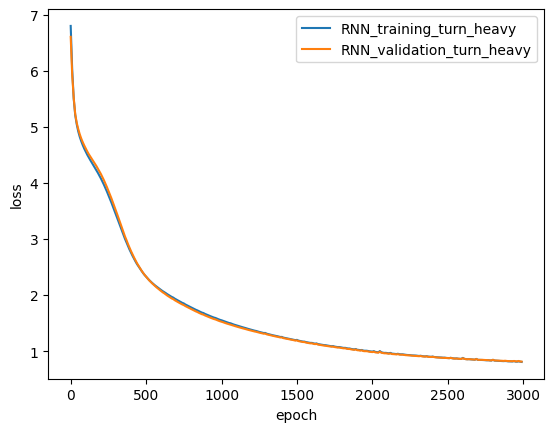

Baseline loss:  9.019743919372559
Baseline loss:  9.019743919372559


,0,1,2
Trajectory count,20.000000,40.000000,80.000000
Trainer MLP Loss,1.399478,1.431543,1.466125
Trainer RNN Loss,0.851628,0.833502,0.808576
Validator MLP Loss,1.488667,1.402863,1.420468
Validator RNN Loss,0.987304,0.876750,0.814342


In [22]:
traj_num = N_TRAJ

traj_list_turn_heavy = []
trainer_MLP_turn_heavy_loss_list = []
trainer_RNN_turn_heavy_loss_list = []
validator_MLP_turn_heavy_loss_list = []
validator_RNN_turn_heavy_loss_list = []
for i in range(3):
    #Generate turn heavy trainer and validator agents

    trainer_inputs_stack_turn_heavy, trainer_target_stack_turn_heavy, trainer_agent_list_turn_heavy = dataset_generator.generate_dataset(grid, trajectories.random_policy, ACTION_PROBS_TURN_HEAVY, VIEW_SIZE, N_STEPS, traj_num, TRAINER_MOVE_SEED, random_start=True, start_seed_start=TRAINER_START_SEED)
    validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy, validator_agent_list_turn_heavy = dataset_generator.generate_dataset(grid, trajectories.random_policy, ACTION_PROBS_TURN_HEAVY, VIEW_SIZE, N_STEPS, 5, VALIDATOR_MOVE_SEED, random_start=True, start_seed_start=VALIDATOR_START_SEED)

    #Train MLP

    INPUT_SIZE_TURN_HEAVY = trainer_inputs_stack_turn_heavy.shape[2]
    OUTPUT_SIZE_TURN_HEAVY = trainer_target_stack_turn_heavy.shape[2]
    HIDDEN_SIZE_TURN_HEAVY = 64     

    model_MLP_turn_heavy = NN_models.SimpleMLP(INPUT_SIZE_TURN_HEAVY, OUTPUT_SIZE_TURN_HEAVY, HIDDEN_SIZE_TURN_HEAVY, "relu")
    MLP_turn_heavy_loss_info = model_training_evaluator.model_training(model_MLP_turn_heavy, trainer_inputs_stack_turn_heavy, trainer_target_stack_turn_heavy, validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy, TRAINING_EPOCHS)
    print(f"MLP Trainer final loss: {MLP_turn_heavy_loss_info[1][-1]}")
    print(f"MLP Validator final loss: {MLP_turn_heavy_loss_info[2][-1]}")
    
    trainer_MLP_turn_heavy_loss_list.append(MLP_turn_heavy_loss_info[1][-1])
    validator_MLP_turn_heavy_loss_list.append(MLP_turn_heavy_loss_info[2][-1])


    model_training_evaluator.plot_training_result(MLP_turn_heavy_loss_info, "epoch", "loss", "MLP_training_turn_heavy", "MLP_validation_turn_heavy")

    #Train RNN

    model_RNN_turn_heavy = NN_models.BasicRNN(INPUT_SIZE_TURN_HEAVY, OUTPUT_SIZE_TURN_HEAVY, HIDDEN_SIZE_TURN_HEAVY, "relu")
    RNN_turn_heavy_loss_info = model_training_evaluator.model_training(model_RNN_turn_heavy, trainer_inputs_stack_turn_heavy, trainer_target_stack_turn_heavy, validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy, TRAINING_EPOCHS)
    print(f"RNN Trainer final loss: {RNN_turn_heavy_loss_info[1][-1]}")
    print(f"RNN Validator final loss: {RNN_turn_heavy_loss_info[2][-1]}")

    model_training_evaluator.plot_training_result(RNN_turn_heavy_loss_info, "epoch", "loss", "RNN_training_turn_heavy", "RNN_validation_turn_heavy")


    trainer_RNN_turn_heavy_loss_list.append(RNN_turn_heavy_loss_info[1][-1])
    validator_RNN_turn_heavy_loss_list.append(RNN_turn_heavy_loss_info[2][-1])


    #Baseline Loss Evaluation

    model_training_evaluator.baseline_evaluation(validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy)
    model_training_evaluator.baseline_evaluation(validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy)

    traj_num *= 2

results_turn_heavy_table_array = []

results_turn_heavy_table_array.append(traj_list)
results_turn_heavy_table_array.append(trainer_MLP_turn_heavy_loss_list)
results_turn_heavy_table_array.append(trainer_RNN_turn_heavy_loss_list)
results_turn_heavy_table_array.append(validator_MLP_turn_heavy_loss_list)
results_turn_heavy_table_array.append(validator_RNN_turn_heavy_loss_list)

results_turn_heavy = pd.DataFrame(
    results_turn_heavy_table_array,
    index = ["Trajectory count", "Trainer MLP Loss", "Trainer RNN Loss", "Validator MLP Loss", "Validator RNN Loss"]
)

results_turn_heavy

Validator Error per Action Type

In [23]:
results_array = []

trainer_RNN_action_losses = model_training_evaluator.evaluator_per_action(model_RNN, trainer_inputs_stack, trainer_target_stack)
validator_RNN_action_losses = model_training_evaluator.evaluator_per_action(model_RNN, validator_inputs_stack, validator_target_stack)

trainer_MLP_action_losses = model_training_evaluator.evaluator_per_action(model_MLP, trainer_inputs_stack, trainer_target_stack)
validator_MLP_action_losses = model_training_evaluator.evaluator_per_action(model_MLP, validator_inputs_stack, validator_target_stack)

results_array.append(trainer_RNN_action_losses)
results_array.append(trainer_MLP_action_losses)
results_array.append(validator_RNN_action_losses)
results_array.append(validator_MLP_action_losses)

results = pd.DataFrame(
    results_array,
    index = ["trainer, RNN", "trainer, MLP", "validator, RNN", "validator, MLP"],
    columns = ["Forward", "Left", "Right", "Stop"]
)

results

,Forward,Left,Right,Stop
"trainer, RNN",0.321713,1.617662,1.552451,1.091653
"trainer, MLP",0.260195,2.102964,2.047692,0.720898
"validator, RNN",0.373015,1.778695,1.838793,1.150829
"validator, MLP",0.297605,2.340745,2.274140,0.777576


Memoryless RNN: How does RNN perform if the hidden state is reset at every step?

In [24]:
memoryless_results_array = []
trainer_RNN_memoryless_per_action_loss = model_training_evaluator.evaluator_per_action_memoryless(model_RNN, trainer_inputs_stack, trainer_target_stack)
validator_RNN_memoryless_per_action_loss = model_training_evaluator.evaluator_per_action_memoryless(model_RNN, validator_inputs_stack, validator_target_stack)


trainer_RNN_turn_heavy_memoryless_per_action_loss = model_training_evaluator.evaluator_per_action_memoryless(model_RNN, trainer_inputs_stack_turn_heavy, trainer_target_stack_turn_heavy)
validator_RNN_turn_heavy_memoryless_per_action_loss = model_training_evaluator.evaluator_per_action_memoryless(model_RNN, validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy)

memoryless_results_array.append(trainer_RNN_action_losses)
memoryless_results_array.append(trainer_RNN_memoryless_per_action_loss)
memoryless_results_array.append(trainer_MLP_action_losses)
memoryless_results_array.append(validator_RNN_action_losses)
memoryless_results_array.append(validator_RNN_memoryless_per_action_loss)
memoryless_results_array.append(validator_MLP_action_losses)

results = pd.DataFrame(
    memoryless_results_array,
    index = ["trainer, RNN", "Trainer RNN Memoryless", "trainer, MLP", "validator, RNN", "Validator RNN Memoryless", "Validator, MLP"],
    columns = ["Forward", "Left", "Right", "Stop"]
)

results

No samples for 3
No samples for 3


,Forward,Left,Right,Stop
"trainer, RNN",0.321713,1.617662,1.552451,1.091653
Trainer RNN Memoryless,0.971820,3.821331,4.121706,1.756465
"trainer, MLP",0.260195,2.102964,2.047692,0.720898
"validator, RNN",0.373015,1.778695,1.838793,1.150829
Validator RNN Memoryless,1.057601,4.120156,4.297479,1.814480
"Validator, MLP",0.297605,2.340745,2.274140,0.777576
